In [1]:
pip install beautifulsoup4 fake-useragent pandas requests nltk transformers datasets tf-keras --upgrade tensorflow statsmodels numpy scipy seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [18]:
data = pd.read_csv('toner_analysis.csv', encoding='latin1')

In [19]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ï»¿index           912 non-null    int64  
 1   Product Name       912 non-null    object 
 2   Price              912 non-null    float64
 3   Description        796 non-null    object 
 4   Reviewer Name      912 non-null    object 
 5   Review Title       912 non-null    object 
 6   Review             912 non-null    object 
 7   Date               912 non-null    object 
 8   Rating             912 non-null    int64  
 9   Verified Purchase  912 non-null    object 
 10  Helpful Votes      912 non-null    int64  
 11  compound           912 non-null    float64
 12  positive           912 non-null    float64
 13  negative           912 non-null    float64
 14  neutral_sentiment  912 non-null    float64
 15  anger              912 non-null    float64
 16  disgust            912 non

In [5]:
# Encode categorical variables
encoder = LabelEncoder()
data['Verified Purchase'] = encoder.fit_transform(data['Verified Purchase'])

# Display the encoded Verified Purchase column
print(data['Verified Purchase'].value_counts())

Verified Purchase
1    895
0     17
Name: count, dtype: int64


In [6]:

data['Review Length'] = data['Review'].apply(len)

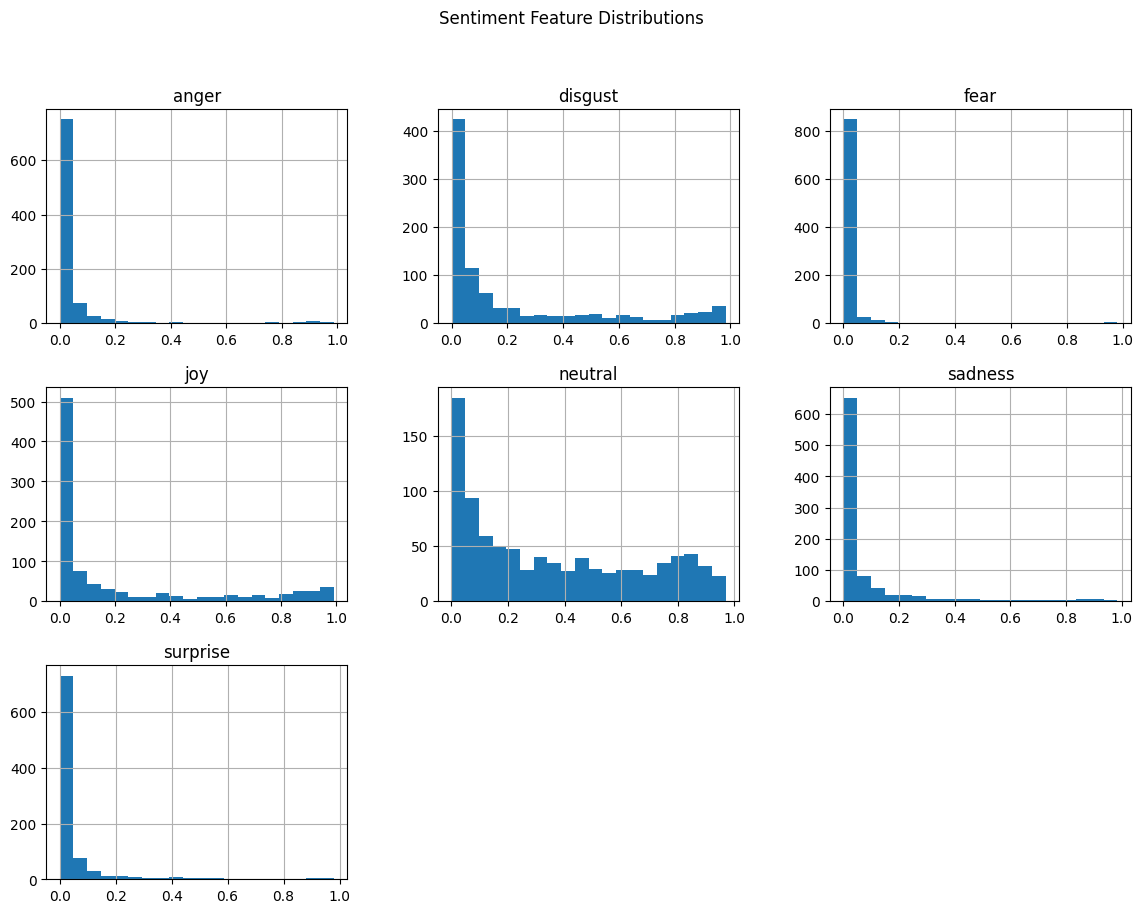

In [20]:
# Selecting sentiment columns for analysis
sentiment_columns = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

# Plotting distribution of sentiment scores
data[sentiment_columns].hist(figsize=(14, 10), bins=20)
plt.suptitle('Sentiment Feature Distributions')
plt.show()

In [8]:
# Selecting features and target
X = data[['Price', 'Verified Purchase', 'Review Length','Helpful Votes'] + sentiment_columns]
y = data['Rating']  # Target variable

In [9]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
pip install mord

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
from mord import LogisticIT

# Fit the ordinal regression model
model = LogisticIT()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.24      0.24      0.24        29
           2       0.00      0.00      0.00        30
           3       0.37      0.45      0.41        64
           4       0.00      0.00      0.00        23
           5       0.66      0.86      0.75       128

    accuracy                           0.53       274
   macro avg       0.25      0.31      0.28       274
weighted avg       0.42      0.53      0.47       274



C:\Users\mraeg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mraeg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mraeg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [12]:
import statsmodels.api as sm
import pandas as pd

# Add a constant for the intercept in the regression model
X = sm.add_constant(X)

# Fit an ordinal regression model using statsmodels
model = sm.OLS(y, X).fit()

# Print the summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     58.28
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           1.07e-90
Time:                        01:51:51   Log-Likelihood:                -1393.9
No. Observations:                 912   AIC:                             2810.
Df Residuals:                     901   BIC:                             2863.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.0381      0.32

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only the independent variables
X_multicollinearity = X.drop('const', axis=1)  # Remove the constant if it's added

# Compute VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multicollinearity.columns
vif_data["VIF"] = [variance_inflation_factor(X_multicollinearity.values, i) for i in range(X_multicollinearity.shape[1])]

# Display VIF values
print(vif_data)

            Variable        VIF
0              Price  14.727482
1  Verified Purchase  16.633317
2      Review Length   1.835325
3      Helpful Votes   1.098792
4              anger   1.321610
5               fear   1.151542
6                joy   2.164446
7            neutral   3.398078
8            sadness   1.564756
9           surprise   1.237967


In [24]:
from sklearn.decomposition import PCA

# Apply PCA to sentiment and emotion features
sentiment_emotion_features = X_multicollinearity[['positive', 'negative', 'neutral_sentiment', 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']]
pca = PCA(n_components=3)  # Choose fewer components
sentiment_emotion_pca = pca.fit_transform(sentiment_emotion_features)

# Replace original features with PCA components
X_multicollinearity = pd.concat([X_multicollinearity[['Price', 'Verified Purchase', 'Review Length']], pd.DataFrame(sentiment_emotion_pca)], axis=1)

KeyError: "None of [Index(['positive', 'negative', 'neutral_sentiment', 'anger', 'disgust', 'fear',\n       'joy', 'neutral', 'sadness', 'surprise'],\n      dtype='object')] are in the [columns]"

In [17]:
from sklearn.decomposition import PCA
import pandas as pd

# Select highly correlated features for PCA
high_corr_features = ['positive', 'negative', 'neutral_sentiment', 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

# Apply PCA to reduce dimensionality
pca = PCA(n_components=3)  # Retain the first 3 principal components
pca_components = pca.fit_transform(X_multicollinearity[high_corr_features])

# Create a DataFrame for the PCA components
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2', 'PCA3'])

# Combine PCA components with non-correlated variables
X_final = pd.concat([X_multicollinearity.drop(high_corr_features, axis=1), pca_df], axis=1)

KeyError: "None of [Index(['positive', 'negative', 'neutral_sentiment', 'anger', 'disgust', 'fear',\n       'joy', 'neutral', 'sadness', 'surprise'],\n      dtype='object')] are in the [columns]"

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Recalculate VIF after PCA
vif_data_final = pd.DataFrame()
vif_data_final["Variable"] = X_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

# Display updated VIF values
print(vif_data_final)

            Variable        VIF
0              Price  13.776792
1  Verified Purchase  14.529419
2      Review Length   1.745582
3               PCA1   1.023065
4               PCA2   1.002977
5               PCA3   1.040603


In [ ]:
correlation = X_final[['Price', 'Verified Purchase']].corr()
print(correlation)

                      Price  Verified Purchase
Price              1.000000           0.029709
Verified Purchase  0.029709           1.000000


In [ ]:
import statsmodels.api as sm

# Add a constant to the dataset
X_final = sm.add_constant(X_final)

# Fit the model
model = sm.OLS(y, X_final).fit()

# Display the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     96.65
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           7.80e-94
Time:                        06:30:04   Log-Likelihood:                -1395.6
No. Observations:                 912   AIC:                             2805.
Df Residuals:                     905   BIC:                             2839.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.3697      0.31

In [ ]:
# Get the loadings for each principal component
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose of PCA components
    columns=['PCA1', 'PCA2', 'PCA3'],  # Name components
    index=high_corr_features  # Original features
)

# Display the loadings
print(loadings)

                       PCA1      PCA2      PCA3
positive           0.293635 -0.030617  0.473345
negative          -0.089566 -0.051210 -0.036224
neutral_sentiment -0.204062  0.081842 -0.437156
anger             -0.048763 -0.019085 -0.129459
disgust           -0.602753 -0.397364  0.503600
fear              -0.020478 -0.010553 -0.058558
joy                0.699600 -0.377276  0.023778
neutral            0.050592  0.829465  0.292138
sadness           -0.077500 -0.031317 -0.426249
surprise          -0.000698  0.006129 -0.205249


In [ ]:
# Select the most dominant variables
dominant_vars = ['joy', 'disgust', 'neutral']

# Prepare the dataset with these variables
X_dominant = X_multicollinearity[dominant_vars]

# Add 'Verified Purchase', 'Price', and 'Review Length' if they remain relevant
X_dominant = pd.concat([X_dominant, X_multicollinearity[['Verified Purchase', 'Price', 'Review Length']]], axis=1)

# Fit the regression model
import statsmodels.api as sm
X_dominant = sm.add_constant(X_dominant)  # Add a constant for the intercept
model = sm.OLS(y, X_dominant).fit()

# Display the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     93.40
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           2.94e-91
Time:                        06:37:20   Log-Likelihood:                -1401.6
No. Observations:                 912   AIC:                             2817.
Df Residuals:                     905   BIC:                             2851.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.2828      0.33

In [ ]:
correlation = X_multicollinearity[['neutral', 'neutral_sentiment']].corr()
print(correlation)

                    neutral  neutral_sentiment
neutral            1.000000           0.074389
neutral_sentiment  0.074389           1.000000
